In [1]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;

In [5]:
df=pd.read_csv('data.csv')

In [6]:
print(df.head())

        location day_of_week  vehicle_count  avg_speed  \
0      Hill Road      Monday            425      45.95   
1    Sector 21-A      Friday            832      21.11   
2      Hill Road    Saturday            958      34.68   
3      Hill Road    Thursday            748      29.73   
4  West Junction      Friday            670      48.25   

                                      incident_notes weather ref_code  
0  Agent every development say quality throughout...  Cloudy     I0Y6  
1  Behavior discussion own night respond red info...   Clear     HSAH  
2  Operation speak according south recently futur...   Foggy     V3A3  
3  Movie win her need stop peace technology offic...  Cloudy     8MDD  
4  Herself law street class great prove reduce ra...   Foggy     T9NT  


In [8]:
df.groupby('day_of_week')['vehicle_count'].mean()

day_of_week
Friday        756.000000
Monday        701.000000
Saturday     1040.750000
Sunday        503.000000
Thursday      613.666667
Tuesday       671.000000
Wednesday     675.000000
Name: vehicle_count, dtype: float64

In [ ]:
avg_traffic=df.groupby('day_of_week')['vehicle_count'].mean()


day_of_week
Friday        756.000000
Monday        701.000000
Saturday     1040.750000
Sunday        503.000000
Thursday      613.666667
Tuesday       671.000000
Wednesday     675.000000
Name: vehicle_count, dtype: float64

In [15]:
avg_traffic>900

day_of_week
Friday       False
Monday       False
Saturday      True
Sunday       False
Thursday     False
Tuesday      False
Wednesday    False
Name: vehicle_count, dtype: bool

In [16]:
avg_traffic[avg_traffic>900]

day_of_week
Saturday    1040.75
Name: vehicle_count, dtype: float64

In [19]:
high_traffic_intersection=df.groupby('location')['vehicle_count'].mean()

In [20]:
high_traffic_intersection

location
City Center      650.000000
Hill Road        825.285714
Sector 21-A      984.000000
Tech Park        638.750000
West Junction    715.500000
Name: vehicle_count, dtype: float64

In [23]:
high_traffic_intersection[high_traffic_intersection>900]

location
Sector 21-A    984.0
Name: vehicle_count, dtype: float64

In [24]:
speeds=df['avg_speed']
speeds

0     45.95
1     21.11
2     34.68
3     29.73
4     48.25
5     40.21
6     33.30
7     42.68
8     27.69
9     22.32
10    28.63
11    23.18
12    33.36
13    50.97
14    29.22
15    25.35
16    23.92
17    45.62
18    38.47
19    54.83
Name: avg_speed, dtype: float64

In [27]:
avg=np.mean(speeds)
sd=np.std(speeds)
v=np.var(speeds)

In [32]:
req=avg-2*sd
req

14.849560748451857

In [39]:
df[df['avg_speed']<req]

,location,day_of_week,vehicle_count,avg_speed,incident_notes,weather,ref_code


In [45]:
y=df.groupby('day_of_week')['vehicle_count'].mean()
y

day_of_week
Friday        756.000000
Monday        701.000000
Saturday     1040.750000
Sunday        503.000000
Thursday      613.666667
Tuesday       671.000000
Wednesday     675.000000
Name: vehicle_count, dtype: float64

In [46]:
x=y.index
x

Index(['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday',
       'Wednesday'],
      dtype='object', name='day_of_week')

In [49]:
max_day=y.idxmax()
max_day

'Saturday'

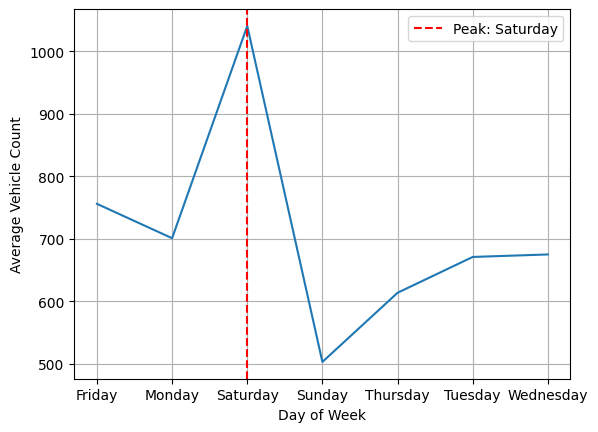

In [51]:
plt.plot(x,y)
plt.xlabel('Day of Week')
plt.ylabel('Average Vehicle Count')
plt.grid(which='major')
plt.grid(which='minor', linestyle=':', linewidth='0.5')
plt.axvline(x=max_day, color='red', linestyle='--', label=f'Peak: {max_day}')
plt.legend()
plt.show()